# USL-Suspilne Dataset Analysis

Comprehensive analysis: split-level stats, outlier detection, vocabulary/OOV, repetitive content, pose sanity checks, and a frame budget. All figures are saved to `reports/figures/dataset/` (PDF + PNG); all tables to `reports/tables/dataset/` (CSV + LaTeX).

**Dependencies:** numpy, matplotlib, pandas


## 1. Load Data

In [1]:
import csv
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Paths ---
ROOT = Path(".").resolve().parent.parent
POSES_DIR = ROOT / "data/usl-suspilne/poses/mediapipe_holistic"
FEATURES_DIR = ROOT / "data/usl-suspilne/features"
SPLIT_DIR = ROOT / "data/usl-suspilne"
FIGURES_DIR = ROOT / "reports/figures/dataset"
TABLES_DIR = ROOT / "reports/tables/dataset"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# --- Constants ---
FPS = 30.0
SPLITS = ["train", "dev", "test"]

# --- QC thresholds (cited verbatim in the thesis "Data quality" section) ---
MIN_DURATION_S = 1.0       # below this: not enough motion signal for a sign
MAX_DURATION_S = 30.0      # above this: likely a segmentation error / unsegmented caption
MIN_TOKENS = 2             # 0-1 tokens are usually fillers ("дякую", "так")
TOKEN_RATE_OUTLIER_Q = 0.01  # flag top/bottom 1% of tokens-per-second

# --- Plot style: matplotlib ggplot ≈ plotnine/ggplot2 look ---
plt.style.use("ggplot")
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})


def savefig(name, fig=None):
    """Save the current figure as both PDF (vector, for LaTeX) and PNG."""
    fig = fig or plt.gcf()
    for ext in ("pdf", "png"):
        fig.savefig(FIGURES_DIR / f"{name}.{ext}")


def npy_n_frames(path):
    """Read frame count via memmap — header is parsed but the array is not copied."""
    return np.load(path, mmap_mode="r").shape[0]


# --- Load split CSVs into a single DataFrame ---
rows = []
for split_name in SPLITS:
    split_csv = SPLIT_DIR / f"{split_name}.csv"
    if not split_csv.exists():
        print(f"WARNING: {split_csv} not found")
        continue
    with open(split_csv, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f, delimiter="|"):
            name = row["name"]
            vid, clip_id = name.split("/")
            text_norm = row["text_norm"]
            pose_path = POSES_DIR / vid / f"{clip_id}.npy"
            n_frames = npy_n_frames(pose_path) if pose_path.exists() else 0
            rows.append({
                "name": name,
                "video_id": vid,
                "clip_id": clip_id,
                "text_norm": text_norm,
                "signer_id": row.get("signer_id", ""),
                "n_frames": n_frames,
                "duration_s": n_frames / FPS,
                "n_tokens": len(text_norm.split()),
                "split": split_name,
            })

df = pd.DataFrame(rows)
print(f"Total clips: {len(df)}")
print(f"Total duration: {df['duration_s'].sum() / 3600:.2f} hours")
print(f"Total frames: {df['n_frames'].sum():,}")
print(f"Clips with poses: {(df['n_frames'] > 0).sum()}")
print(f"Videos: {df['video_id'].nunique()}")
print(f"Signers: {df['signer_id'].nunique()}")
df.head()

Total clips: 2114
Total duration: 3.39 hours
Total frames: 366,266
Clips with poses: 2114
Videos: 11
Signers: 5


,name,video_id,clip_id,text_norm,signer_id,n_frames,duration_s,n_tokens,split
0,v00/0000,v00,0000,інформаційний проєкт суспільна студія повертає...,0,114,3.800000,8,train
1,v00/0002,v00,0002,як стало попередньо відомо він завітав на один...,0,307,10.233333,15,train
2,v00/0003,v00,0003,і зараз наші глядачі можуть побачити промову,0,102,3.400000,7,train
3,v00/0005,v00,0005,також приїхав він до виборчої дільниці зі своє...,0,190,6.333333,10,train
4,v00/0007,v00,0007,також додамо що зараз дональд трамп перебуває ...,0,176,5.866667,11,train


## 2. Overview by Video & Signer

In [2]:
# Clips per video
video_stats = df.groupby("video_id").agg(
    clips=("name", "count"),
    duration_min=("duration_s", lambda x: x.sum() / 60),
    split=("split", "first"),
    signers=("signer_id", lambda x: ",".join(sorted(set(x)))),
).sort_values("clips", ascending=False)

print(video_stats.to_string())
print(f"\nTotal videos: {len(video_stats)}")

          clips  duration_min  split signers
video_id                                    
v02         481     36.608889  train     3,4
v09         423     37.103333  train       2
v06         215     19.572222  train     3,4
v08         178     22.356111  train       0
v10         147     13.293333  train       0
v04         146     16.453889  train       0
v07         145     11.688333  train       0
v05         118     10.818333  train       0
v01         115     15.410556  train       1
v00          85     12.332778  train       0
v03          61      7.843333  train       0

Total videos: 11


In [3]:
# Per-signer breakdown: clips, minutes, sentences, tokens, vocabulary contribution
def signer_agg(group):
    tokens = [t for text in group["text_norm"] for t in text.split()]
    return pd.Series({
        "clips": len(group),
        "minutes": group["duration_s"].sum() / 60,
        "sentences": (group["n_tokens"] > 0).sum(),
        "tokens_total": len(tokens),
        "types_unique": len(set(tokens)),
        "videos": group["video_id"].nunique(),
        "splits": ",".join(sorted(set(group["split"]))),
    })

signer_stats = (df.groupby("signer_id", dropna=False)
                  .apply(signer_agg, include_groups=False)
                  .sort_values("clips", ascending=False))

# Share-of-vocabulary contribution: tokens unique to this signer in train
train_df = df[df["split"] == "train"]
train_vocab_by_signer = {
    sid: set(t for text in g["text_norm"] for t in text.split())
    for sid, g in train_df.groupby("signer_id", dropna=False)
}
all_train_vocab = set().union(*train_vocab_by_signer.values()) if train_vocab_by_signer else set()
exclusive_types = {sid: len(v - set().union(*[w for k, w in train_vocab_by_signer.items() if k != sid]))
                   for sid, v in train_vocab_by_signer.items()}
signer_stats["types_exclusive_to_train"] = signer_stats.index.map(exclusive_types).fillna(0).astype(int)

print(signer_stats.round(2).to_string())
signer_stats.to_csv(TABLES_DIR / "per_signer.csv")
with open(TABLES_DIR / "per_signer.tex", "w") as f:
    f.write(signer_stats.round(2).to_latex())


           clips  minutes  sentences  tokens_total  types_unique  videos          splits  types_exclusive_to_train
signer_id                                                                                                         
0            880    94.79        880         11068          3518       7  dev,test,train                      1854
3            511    42.60        511          4573          2298       2  dev,test,train                      1113
2            423    37.10        423          4921          2155       1  dev,test,train                       781
4            185    13.58        185          1560           891       2  dev,test,train                       328
1            115    15.41        115          1806           937       1  dev,test,train                       319


--- Clip distribution: per signer and per source video ---


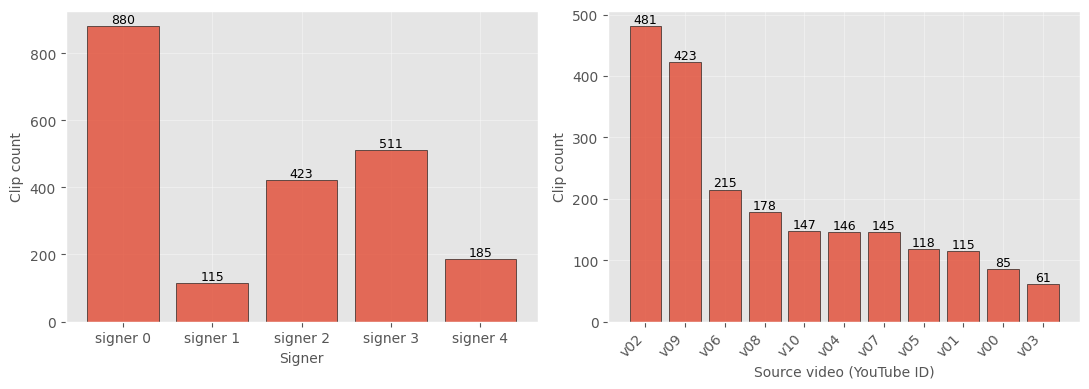

In [4]:
print("--- Clip distribution: per signer and per source video ---")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Per signer
signer_counts = df["signer_id"].value_counts().sort_index()
axes[0].bar([f"signer {s}" for s in signer_counts.index], signer_counts.values,
            edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Signer")
axes[0].set_ylabel("Clip count")
for i, v in enumerate(signer_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

# Per source video, sorted by count
video_counts = df["video_id"].value_counts().sort_values(ascending=False)
axes[1].bar(range(len(video_counts)), video_counts.values,
            edgecolor="black", alpha=0.8)
axes[1].set_xticks(range(len(video_counts)))
axes[1].set_xticklabels(video_counts.index, rotation=45, ha="right")
axes[1].set_xlabel("Source video (YouTube ID)")
axes[1].set_ylabel("Clip count")
for i, v in enumerate(video_counts.values):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
savefig("clips_per_signer_video")
plt.show()


## 3. Split Analysis

In [5]:
split_stats = df.groupby("split").agg(
    clips=("name", "count"),
    hours=("duration_s", lambda x: x.sum() / 3600),
    videos=("video_id", "nunique"),
    avg_tokens=("n_tokens", "mean"),
    avg_duration=("duration_s", "mean"),
).reindex(SPLITS)

split_stats["clip_%"] = split_stats["clips"] / split_stats["clips"].sum() * 100
split_stats["hour_%"] = split_stats["hours"] / split_stats["hours"].sum() * 100

print(split_stats.round(2).to_string())

       clips  hours  videos  avg_tokens  avg_duration  clip_%  hour_%
split                                                                
train   1691   2.73      11       11.42          5.81   79.99   80.45
dev      211   0.32      11       10.89          5.53    9.98    9.56
test     212   0.34      11       10.98          5.75   10.03    9.99


--- Clip Duration Distribution per Split ---


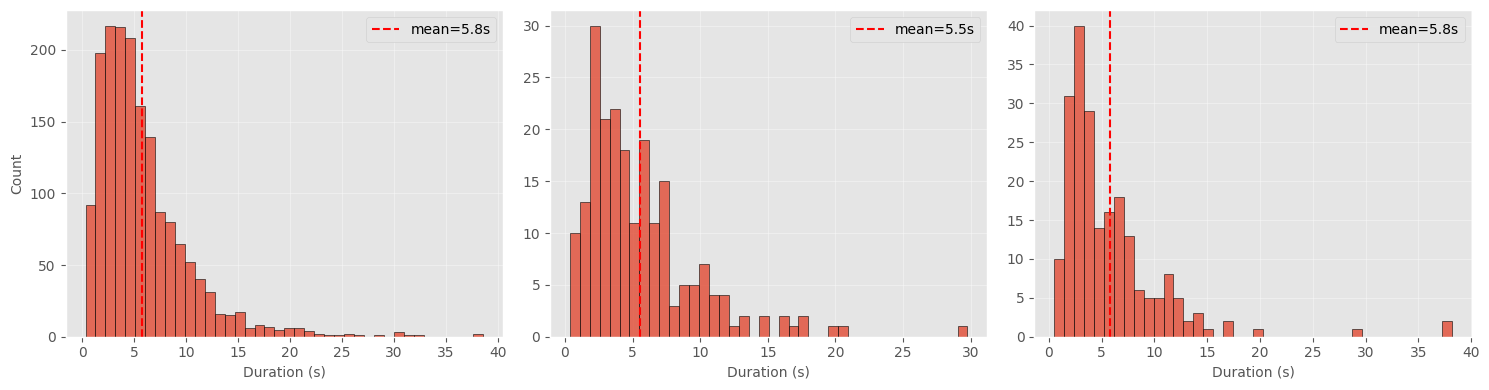

In [6]:
print("--- Clip Duration Distribution per Split ---")
fig, axes = plt.subplots(1, len(SPLITS), figsize=(5 * len(SPLITS), 4))

for ax, split in zip(axes, SPLITS):
    subset = df[df["split"] == split]
    if len(subset) == 0:
        ax.set_xlabel("Duration (s)")
        continue
    ax.hist(subset["duration_s"], bins=40, edgecolor="black", alpha=0.8)
    ax.axvline(subset["duration_s"].mean(), color="red", linestyle="--",
               label=f"mean={subset['duration_s'].mean():.1f}s")
    ax.set_xlabel("Duration (s)")
    ax.legend()

axes[0].set_ylabel("Count")
plt.tight_layout()
savefig("duration_per_split")
plt.show()


--- Sentence Length Distribution per Split ---


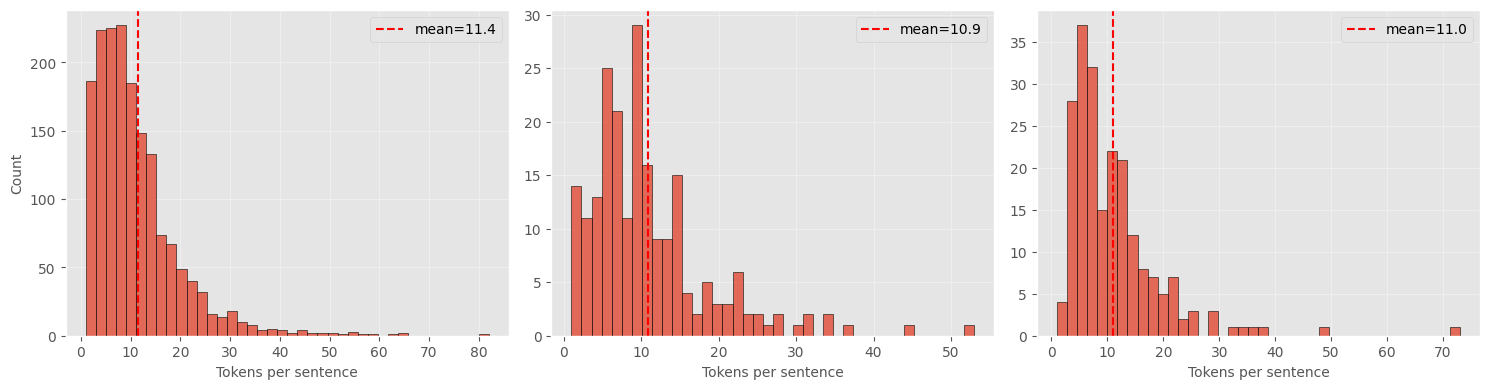

In [7]:
print("--- Sentence Length Distribution per Split ---")
fig, axes = plt.subplots(1, len(SPLITS), figsize=(5 * len(SPLITS), 4))

for ax, split in zip(axes, SPLITS):
    subset = df[df["split"] == split]
    if len(subset) == 0:
        ax.set_xlabel("Tokens per sentence")
        continue
    ax.hist(subset["n_tokens"], bins=40, edgecolor="black", alpha=0.8)
    ax.axvline(subset["n_tokens"].mean(), color="red", linestyle="--",
               label=f"mean={subset['n_tokens'].mean():.1f}")
    ax.set_xlabel("Tokens per sentence")
    ax.legend()

axes[0].set_ylabel("Count")
plt.tight_layout()
savefig("tokens_per_split")
plt.show()


### Sentence-rate distribution (tokens/sec)

Sanity check: Ukrainian speech sits around 2–3 tokens/sec. Outliers indicate alignment errors.

--- Token-Rate Distribution per Split ---


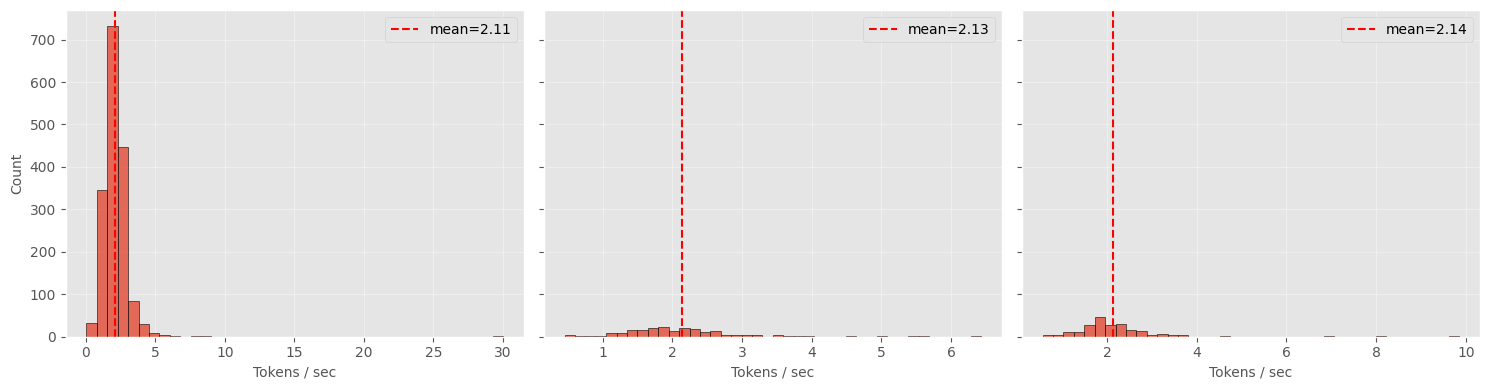

In [8]:
df["tokens_per_sec"] = df["n_tokens"] / df["duration_s"].replace(0, np.nan)

print("--- Token-Rate Distribution per Split ---")
fig, axes = plt.subplots(1, len(SPLITS), figsize=(5 * len(SPLITS), 4), sharey=True)
for ax, split in zip(axes, SPLITS):
    subset = df[df["split"] == split].dropna(subset=["tokens_per_sec"])
    if len(subset) == 0:
        ax.set_xlabel("Tokens / sec")
        continue
    ax.hist(subset["tokens_per_sec"], bins=40, edgecolor="black", alpha=0.8)
    ax.axvline(subset["tokens_per_sec"].mean(), color="red", linestyle="--",
               label=f"mean={subset['tokens_per_sec'].mean():.2f}")
    ax.set_xlabel("Tokens / sec")
    ax.legend()
axes[0].set_ylabel("Count")
plt.tight_layout()
savefig("token_rate_per_split")
plt.show()

## 4. Outlier Detection

We flag clips that may hurt training quality. Thresholds are constants defined in the setup cell so they can be cited directly in the thesis:

| Flag | Threshold | Rationale |
|---|---|---|
| `flag_short` | `duration_s < MIN_DURATION_S` (1.0 s) | Not enough motion signal for a meaningful sign |
| `flag_long` | `duration_s > MAX_DURATION_S` (30.0 s) | Likely segmentation error / unsegmented caption |
| `flag_no_pose` | `n_frames == 0` | Pose extraction failed |
| `flag_single_tok` | `n_tokens < MIN_TOKENS` (2) | Filler words ("так", "дякую") have weak text↔motion alignment |
| `flag_high_rate` | `tokens_per_sec` in top `TOKEN_RATE_OUTLIER_Q` (1%) | Text too long for clip duration (alignment error) |
| `flag_low_rate` | `tokens_per_sec` in bottom `TOKEN_RATE_OUTLIER_Q` (1%) | Clip too long for text (alignment error) |


In [9]:
df["tokens_per_sec"] = df["n_tokens"] / df["duration_s"].replace(0, np.nan)

df["flag_short"] = df["duration_s"] < MIN_DURATION_S
df["flag_long"] = df["duration_s"] > MAX_DURATION_S
df["flag_no_pose"] = df["n_frames"] == 0
df["flag_single_tok"] = df["n_tokens"] < MIN_TOKENS
df["flag_high_rate"] = df["tokens_per_sec"] > df["tokens_per_sec"].quantile(1 - TOKEN_RATE_OUTLIER_Q)
df["flag_low_rate"] = df["tokens_per_sec"] < df["tokens_per_sec"].quantile(TOKEN_RATE_OUTLIER_Q)
df["flag_any"] = df[["flag_short", "flag_long", "flag_no_pose", "flag_single_tok",
                      "flag_high_rate", "flag_low_rate"]].any(axis=1)

outlier_summary = pd.DataFrame({
    "Category": [f"< {MIN_DURATION_S}s duration", f"> {MAX_DURATION_S}s duration",
                 "Missing poses", f"< {MIN_TOKENS} tokens",
                 f"Top {TOKEN_RATE_OUTLIER_Q*100:.0f}% token rate",
                 f"Bottom {TOKEN_RATE_OUTLIER_Q*100:.0f}% token rate", "Any flag"],
    "Count": [df["flag_short"].sum(), df["flag_long"].sum(), df["flag_no_pose"].sum(),
              df["flag_single_tok"].sum(), df["flag_high_rate"].sum(),
              df["flag_low_rate"].sum(), df["flag_any"].sum()],
})
outlier_summary["% of dataset"] = (outlier_summary["Count"] / len(df) * 100).round(1)
outlier_summary.to_csv(TABLES_DIR / "outlier_summary.csv", index=False)
outlier_summary


,Category,Count,% of dataset
0,< 1.0s duration,47,2.2
1,> 30.0s duration,9,0.4
2,Missing poses,0,0.0
3,< 2 tokens,22,1.0
4,Top 1% token rate,22,1.0
5,Bottom 1% token rate,22,1.0
6,Any flag,97,4.6


### 4a. Very short clips (< 1s)

In [10]:
short = df[df["flag_short"]].sort_values("duration_s")
print(f"{len(short)} clips under 1 second")
short[["name", "split", "duration_s", "n_tokens", "text_norm"]].head(15)

47 clips under 1 second


,name,split,duration_s,n_tokens,text_norm
518,v02/0460,train,0.333333,3,у її обов'язках
1884,v09/0384,dev,0.366667,2,мета першочергова
1516,v09/0360,train,0.366667,1,ось
1195,v08/0136,train,0.433333,13,тут ніяких особливостей в порівнянні з звичайн...
703,v04/0135,train,0.433333,2,не дуже
371,v02/0276,train,0.466667,2,люди неушкоджені
882,v06/0105,train,0.500000,1,дякую
2110,v10/0117,test,0.500000,4,а які ми сепаратисти
1062,v07/0112,train,0.600000,2,у багатоповерхівках
860,v06/0069,train,0.600000,1,дякую


### 4b. Very long clips (> 30s)

In [11]:
long = df[df["flag_long"]].sort_values("duration_s", ascending=False)
print(f"{len(long)} clips over 30 seconds")
long[["name", "split", "duration_s", "n_tokens", "text_norm"]]

9 clips over 30 seconds


,name,split,duration_s,n_tokens,text_norm
102,v01/0043,train,38.600000,82,зараз буде дуже суб'єктивна моя оцінка не треб...
684,v04/0112,train,38.366667,64,от звісно якщо до нашої роботи власне буде пов...
1914,v01/0046,test,38.166667,73,він чудово мабуть розуміє що це насправді підв...
2087,v09/0295,test,38.000000,36,не евакуювалися з міста ситуація в місті вкрай...
67,v00/0079,train,32.066667,64,цим ми зараз теж займаємось я нещодавно поверн...
106,v01/0050,train,31.400000,53,дякуємо дуже за ваш коментар олександр голубов...
1118,v08/0039,train,30.566667,54,двадцять другий рік багато в двадцять третьому...
62,v00/0074,train,30.166667,40,якщо діаспора проживає на тихоокеанському узбе...
280,v02/0158,train,30.100000,44,головний тому що росія чинить злочини порушує ...


### 4c. Missing poses & single-token clips

In [12]:
missing = df[df["flag_no_pose"]]
print(f"Missing poses: {len(missing)}")
if len(missing) > 0:
    display(missing[["name", "split", "n_tokens", "text_norm"]])

print(f"\nSingle-token clips: {df['flag_single_tok'].sum()}")
single = df[df["flag_single_tok"]]
single_words = Counter(single["text_norm"])
print("\nMost common single-token texts:")
for word, count in single_words.most_common(15):
    print(f"  {word:<20} {count:>3}x")

Missing poses: 0

Single-token clips: 22

Most common single-token texts:
  вітаю                  4x
  дякую                  3x
  вітання                1x
  нічого                 1x
  черпак                 1x
  так                    1x
  жодного                1x
  відновлюємо            1x
  зрозуміло              1x
  одразу                 1x
  немає                  1x
  змінюється             1x
  привіт                 1x
  ось                    1x
  грінченко              1x


### 4d. Token-rate outliers (text ↔ duration mismatch)

In [13]:
print("Token rate (tokens/sec) percentiles:")
print(df["tokens_per_sec"].describe().round(2).to_string())

print(f"\n--- Top 1% rate (>{df['tokens_per_sec'].quantile(0.99):.1f} tok/s) — text too long for clip duration ---")
high = df[df["flag_high_rate"]].sort_values("tokens_per_sec", ascending=False)
display(high[["name", "split", "duration_s", "n_tokens", "tokens_per_sec", "text_norm"]].head(10))

print(f"\n--- Bottom 1% rate (<{df['tokens_per_sec'].quantile(0.01):.1f} tok/s) — clip too long for text ---")
low = df[df["flag_low_rate"]].sort_values("tokens_per_sec")
display(low[["name", "split", "duration_s", "n_tokens", "tokens_per_sec", "text_norm"]].head(10))

Token rate (tokens/sec) percentiles:
count    2114.00
mean        2.12
std         1.01
min         0.06
25%         1.62
50%         2.00
75%         2.46
max        30.00

--- Top 1% rate (>4.8 tok/s) — text too long for clip duration ---


,name,split,duration_s,n_tokens,tokens_per_sec,text_norm
1195,v08/0136,train,0.433333,13,30.000000,тут ніяких особливостей в порівнянні з звичайн...
2051,v08/0151,test,2.233333,22,9.850746,ще в вересні набув чинності закон що дозволяє ...
518,v02/0460,train,0.333333,3,9.000000,у її обов'язках
311,v02/0198,train,0.933333,8,8.571429,вони просто були навколо харкова з усіх боків
2110,v10/0117,test,0.500000,4,8.000000,а які ми сепаратисти
1207,v08/0149,train,2.766667,22,7.951807,якщо щодо нього вже наявний вирок якщо він зас...
1921,v01/0103,test,1.900000,13,6.842105,вони шукають багато причин чому їм не вдалося ...
1226,v08/0173,train,2.766667,18,6.506024,його командир має надати письмове погодження н...
1738,v02/0211,dev,0.933333,6,6.428571,я практично втратив свідомість від удару
607,v04/0018,train,0.633333,4,6.315789,але так не працює



--- Bottom 1% rate (<0.6 tok/s) — clip too long for text ---


,name,split,duration_s,n_tokens,tokens_per_sec,text_norm
1196,v08/0137,train,17.100000,1,0.058480,немає
689,v04/0118,train,6.066667,1,0.164835,жодного
143,v01/0101,train,8.766667,3,0.342205,демократична партія переживає
527,v02/0473,train,2.333333,1,0.428571,так
1848,v08/0141,dev,8.800000,4,0.454545,або ми говоримо про
1850,v08/0174,dev,6.400000,3,0.468750,дякуємо що долучились
1767,v03/0013,dev,2.000000,1,0.500000,вітаємо
1221,v08/0167,train,21.900000,11,0.502283,цим займається державне бюро розслідувань яке ...
1208,v08/0150,train,11.533333,6,0.520231,буде направлений до місць позбавлення волі
1224,v08/0170,train,22.766667,12,0.527086,потрібні документи військово-обліковий докумен...


### 4e. Impact of removing flagged clips

In [14]:
clean = df[~df["flag_any"]]
print(f"Before filtering: {len(df):>5} clips, {df['duration_s'].sum()/3600:.2f}h")
print(f"After filtering:  {len(clean):>5} clips, {clean['duration_s'].sum()/3600:.2f}h")
print(f"Removed:          {len(df)-len(clean):>5} clips, {(df['duration_s'].sum()-clean['duration_s'].sum())/3600:.2f}h")
print()

for split in SPLITS:
    before = df[df["split"] == split]
    after = clean[clean["split"] == split]
    print(f"  {split}: {len(before)} → {len(after)} clips "
          f"({before['duration_s'].sum()/3600:.2f}h → {after['duration_s'].sum()/3600:.2f}h)")

Before filtering:  2114 clips, 3.39h
After filtering:   2017 clips, 3.24h
Removed:             97 clips, 0.16h

  train: 1691 → 1613 clips (2.73h → 2.60h)
  dev: 211 → 199 clips (0.32h → 0.32h)
  test: 212 → 205 clips (0.34h → 0.31h)


## 5. Vocabulary & OOV

In [15]:
# Vocabulary and OOV
eval_splits = [s for s in SPLITS if s != "train"]

split_tokens = {s: [t for text in df[df["split"] == s]["text_norm"] for t in text.split()] for s in SPLITS}
train_vocab = set(split_tokens["train"])

print(f"{'Split':<14} {'Tokens':>8} {'Types':>7}")
print("-" * 34)
for s in SPLITS:
    types = len(set(split_tokens[s]))
    print(f"{s:<14} {len(split_tokens[s]):>8} {types:>7}")

print(f"\n{'Split':<14} {'OOV tokens':>11} {'OOV %':>7} {'OOV types':>10} {'OOV type %':>11}")
print("-" * 58)
for s in eval_splits:
    tokens = split_tokens[s]
    types = set(tokens)
    oov_tokens = [t for t in tokens if t not in train_vocab]
    oov_types = types - train_vocab
    print(f"{s:<14} {len(oov_tokens):>11} {len(oov_tokens)/max(len(tokens),1)*100:>6.1f}% "
          f"{len(oov_types):>10} {len(oov_types)/max(len(types),1)*100:>10.1f}%")

train_tokens_all = split_tokens["train"]

Split            Tokens   Types
----------------------------------
train             19303    5920
dev                2297    1338
test               2328    1338

Split           OOV tokens   OOV %  OOV types  OOV type %
----------------------------------------------------------
dev                    436   19.0%        427       31.9%
test                   469   20.1%        448       33.5%


### Frequency distribution & Zipf

In [16]:
train_counter = Counter(train_tokens_all)
vocab_size = len(train_counter)
total_tokens = sum(train_counter.values())

print(f"Train vocabulary: {vocab_size} types, {total_tokens} tokens")
print()

# Frequency buckets
freq_buckets = {"1": 0, "2": 0, "3-5": 0, "6-10": 0, "11-50": 0, "51+": 0}
for word, count in train_counter.items():
    if count == 1:
        freq_buckets["1"] += 1
    elif count == 2:
        freq_buckets["2"] += 1
    elif count <= 5:
        freq_buckets["3-5"] += 1
    elif count <= 10:
        freq_buckets["6-10"] += 1
    elif count <= 50:
        freq_buckets["11-50"] += 1
    else:
        freq_buckets["51+"] += 1

print(f"{'Frequency':<12} {'Types':>7} {'% of vocab':>10}")
print("-" * 32)
for bucket, count in freq_buckets.items():
    print(f"{bucket:<12} {count:>7} {count / vocab_size * 100:>9.1f}%")

hapax = freq_buckets["1"]
print(f"\nHapax legomena: {hapax} / {vocab_size} = {hapax / vocab_size * 100:.1f}% of vocabulary")

Train vocabulary: 5920 types, 19303 tokens

Frequency      Types % of vocab
--------------------------------
1               3687      62.3%
2                982      16.6%
3-5              737      12.4%
6-10             289       4.9%
11-50            184       3.1%
51+               41       0.7%

Hapax legomena: 3687 / 5920 = 62.3% of vocabulary


--- Zipf's Law and Vocabulary Coverage ---


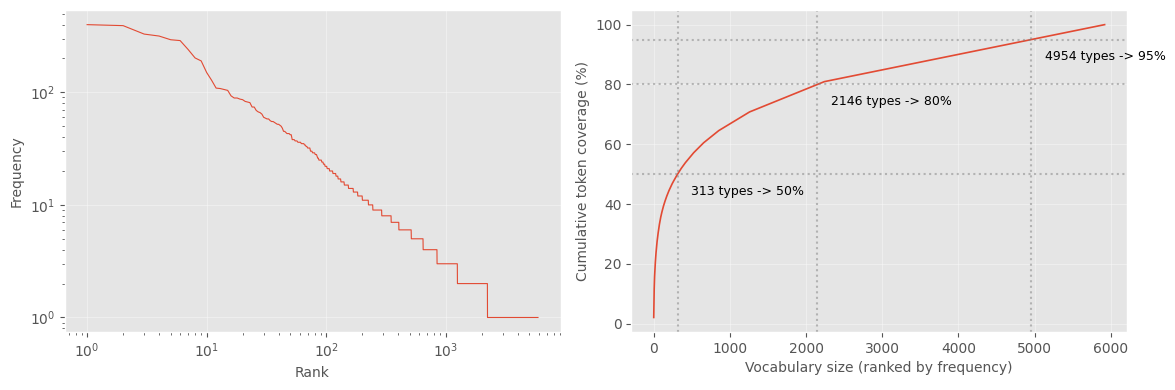

In [17]:
sorted_counts = sorted(train_counter.values(), reverse=True)
ranks = np.arange(1, len(sorted_counts) + 1)

print("--- Zipf's Law and Vocabulary Coverage ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.loglog(ranks, sorted_counts, "-", linewidth=0.8)
ax1.set_xlabel("Rank")
ax1.set_ylabel("Frequency")

cumsum = np.cumsum(sorted_counts) / sum(sorted_counts) * 100
ax2.plot(ranks, cumsum, "-", linewidth=1.2)
for pct in [50, 80, 95]:
    idx = np.searchsorted(cumsum, pct)
    ax2.axhline(pct, color="gray", linestyle=":", alpha=0.5)
    ax2.axvline(idx, color="gray", linestyle=":", alpha=0.5)
    ax2.annotate(f"{idx} types -> {pct}%", (idx, pct),
                 textcoords="offset points", xytext=(10, -15), fontsize=9)
ax2.set_xlabel("Vocabulary size (ranked by frequency)")
ax2.set_ylabel("Cumulative token coverage (%)")

plt.tight_layout()
savefig("zipf_coverage")
plt.show()


## 6. Repetitive Content (Most Frequent N-grams)

News broadcasts over-represent stock phrases (sign-off lines, programme titles). High-frequency n-grams are useful both as a quality signal (do they reflect topic, or boilerplate?) and to motivate down-weighting / data-augmentation strategies.

In [18]:
def top_ngrams(texts, n, k=50):
    counter = Counter()
    for text in texts:
        toks = text.split()
        for i in range(len(toks) - n + 1):
            counter[" ".join(toks[i:i+n])] += 1
    return counter.most_common(k)

train_texts = df[df["split"] == "train"]["text_norm"].tolist()

bigrams = top_ngrams(train_texts, n=2, k=50)
trigrams = top_ngrams(train_texts, n=3, k=50)

bigram_df = pd.DataFrame(bigrams, columns=["bigram", "count"])
trigram_df = pd.DataFrame(trigrams, columns=["trigram", "count"])

print("Top 25 bigrams (train split):")
print(bigram_df.head(25).to_string(index=False))
print(f"\nTop 25 trigrams (train split):")
print(trigram_df.head(25).to_string(index=False))

bigram_df.to_csv(TABLES_DIR / "top_bigrams.csv", index=False)
trigram_df.to_csv(TABLES_DIR / "top_trigrams.csv", index=False)


Top 25 bigrams (train split):
           bigram  count
            те що     50
          тому що     44
          під час     29
       дві тисячі     24
           про те     24
сполучених штатів     20
            у сша     20
           про це     17
     у сполучених     16
сполучених штатах     16
            у нас     16
          я думаю     16
           ж таки     15
            що ми     14
         для того     14
             я не     14
         думаю що     14
            що це     14
         того щоб     13
            з них     13
        в україні     12
          а також     12
  тисячі двадцять     12
            все ж     12
   штатах америки     11

Top 25 trigrams (train split):
                           trigram  count
                         про те що     21
               у сполучених штатах     16
               дві тисячі двадцять     12
                      для того щоб     12
                        все ж таки     12
                        я думаю що  

## 7. Signers and Pose Sanity Checks

Three figures, in order:

1. **Signer montage** — one representative frame per signer with clip count. Visual "who signs in this dataset".
2. **Mean pose per signer** — average (x, y) of the 33 body keypoints across every frame each signer appears in. Sanity-checks that the cropped region is consistent.
3. **Wrist-position heatmap per signer** — 2D histogram of left- and right-wrist coordinates, showing each signer's signing space.


--- Representative frame per signer ---


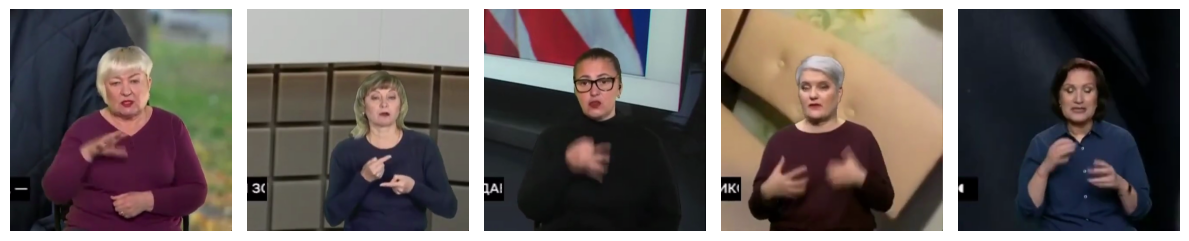

In [19]:
import cv2

# --- Figure: Signer montage (one representative frame per signer) ---
signers = sorted(s for s in df["signer_id"].dropna().unique() if s != "")

print("--- Representative frame per signer ---")
fig, axes = plt.subplots(1, len(signers), figsize=(2.4 * len(signers), 3))
if len(signers) == 1:
    axes = [axes]

for ax, sid in zip(axes, signers):
    signer_clips = df[df["signer_id"] == sid].sort_values("name")
    if len(signer_clips) == 0:
        ax.axis("off")
        continue
    row = signer_clips.iloc[len(signer_clips) // 2]
    vid, clip = row["name"].split("/")
    mp4 = FEATURES_DIR / vid / f"{clip}.mp4"
    cap = cv2.VideoCapture(str(mp4))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, n // 2)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        ax.axis("off")
        continue
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    ax.imshow(rgb)
    ax.axis("off")

plt.tight_layout()
savefig("signer_montage")
plt.show()


--- MediaPipe Holistic overlay (sample frame) ---


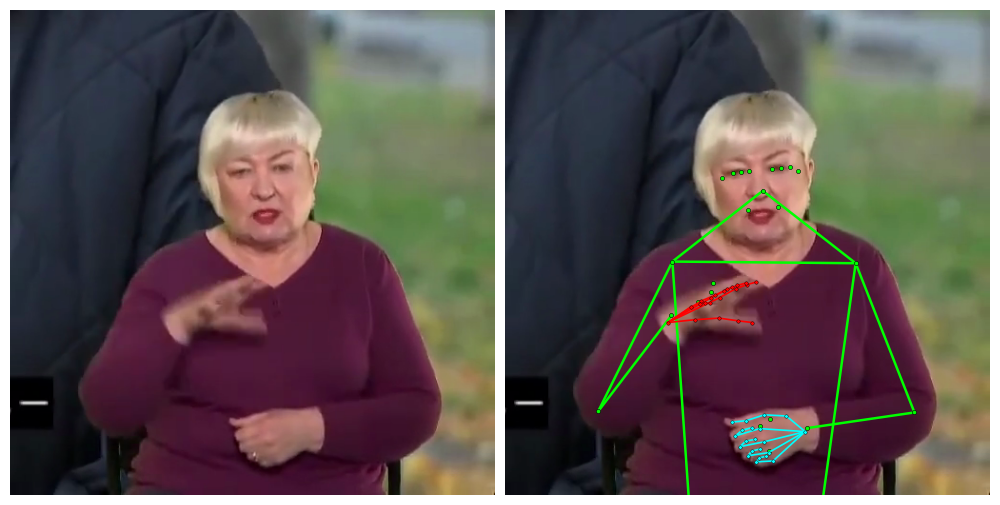

In [20]:
print("--- MediaPipe Holistic overlay (sample frame) ---")

# Pick a sample clip from the largest signer for reliable detections
sid = df["signer_id"].value_counts().idxmax()
sample = df[df["signer_id"] == sid].sort_values("name")
row = sample.iloc[len(sample) // 2]
vid, clip = row["name"].split("/")
mp4_path = FEATURES_DIR / vid / f"{clip}.mp4"
pose_path = POSES_DIR / vid / f"{clip}.npy"

cap = cv2.VideoCapture(str(mp4_path))
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.set(cv2.CAP_PROP_POS_FRAMES, n_frames // 2)
_, frame = cap.read()
cap.release()
rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
h, w = rgb.shape[:2]

joints = np.load(pose_path).reshape(-1, 75, 3)[n_frames // 2]  # (75, 3)

# MediaPipe Pose body skeleton (subset relevant to upper body / arms)
BODY_EDGES = [
    (11, 12),                                  # shoulders
    (11, 13), (13, 15),                        # left arm
    (12, 14), (14, 16),                        # right arm
    (11, 23), (12, 24), (23, 24),              # torso
    (0, 11), (0, 12),                          # neck
]
# MediaPipe Hand connectivity (21 landmarks)
HAND_EDGES = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (0, 5), (5, 6), (6, 7), (7, 8),
    (0, 9), (9, 10), (10, 11), (11, 12),
    (0, 13), (13, 14), (14, 15), (15, 16),
    (0, 17), (17, 18), (18, 19), (19, 20),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), facecolor="white")
for ax in axes:
    ax.imshow(rgb)
    ax.axis("off")
    ax.set_facecolor("white")

ov = axes[1]

# Body skeleton (green)
for a, b in BODY_EDGES:
    pa, pb = joints[a], joints[b]
    if pa[2] > 0.3 and pb[2] > 0.3:
        ov.plot([pa[0] * w, pb[0] * w], [pa[1] * h, pb[1] * h],
                color="lime", linewidth=1.8)
for j in range(33):
    if joints[j, 2] > 0.3:
        ov.plot(joints[j, 0] * w, joints[j, 1] * h, "o",
                color="lime", markersize=3, markeredgecolor="black", markeredgewidth=0.4)

# Hands: left=cyan, right=red. Hand 3rd channel is 1.0 when detected, 0.0 when missing.
for hand_start, color in [(33, "cyan"), (54, "red")]:
    if joints[hand_start, 2] == 0:
        continue
    for a, b in HAND_EDGES:
        pa, pb = joints[hand_start + a], joints[hand_start + b]
        ov.plot([pa[0] * w, pb[0] * w], [pa[1] * h, pb[1] * h],
                color=color, linewidth=1.2)
    for j in range(21):
        p = joints[hand_start + j]
        ov.plot(p[0] * w, p[1] * h, "o", color=color, markersize=2.5,
                markeredgecolor="black", markeredgewidth=0.3)

for ax in axes:
    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)  # invert: image origin is top-left
plt.subplots_adjust(wspace=0.02, left=0.01, right=0.99, top=0.99, bottom=0.01)
savefig("pose_overlay")
plt.show()


--- Mean body pose per signer (33 MediaPipe keypoints) ---


/var/folders/fd/hjgg2r9x2zb9xlpcj2j01qyw0000gn/T/ipykernel_4367/3751594577.py:40: RuntimeWarning: Mean of empty slice
  mean_xy = np.nanmean(mean_xy, axis=0)  # (33, 2)
/var/folders/fd/hjgg2r9x2zb9xlpcj2j01qyw0000gn/T/ipykernel_4367/3751594577.py:40: RuntimeWarning: Mean of empty slice
  mean_xy = np.nanmean(mean_xy, axis=0)  # (33, 2)
/var/folders/fd/hjgg2r9x2zb9xlpcj2j01qyw0000gn/T/ipykernel_4367/3751594577.py:40: RuntimeWarning: Mean of empty slice
  mean_xy = np.nanmean(mean_xy, axis=0)  # (33, 2)
/var/folders/fd/hjgg2r9x2zb9xlpcj2j01qyw0000gn/T/ipykernel_4367/3751594577.py:40: RuntimeWarning: Mean of empty slice
  mean_xy = np.nanmean(mean_xy, axis=0)  # (33, 2)
/var/folders/fd/hjgg2r9x2zb9xlpcj2j01qyw0000gn/T/ipykernel_4367/3751594577.py:40: RuntimeWarning: Mean of empty slice
  mean_xy = np.nanmean(mean_xy, axis=0)  # (33, 2)


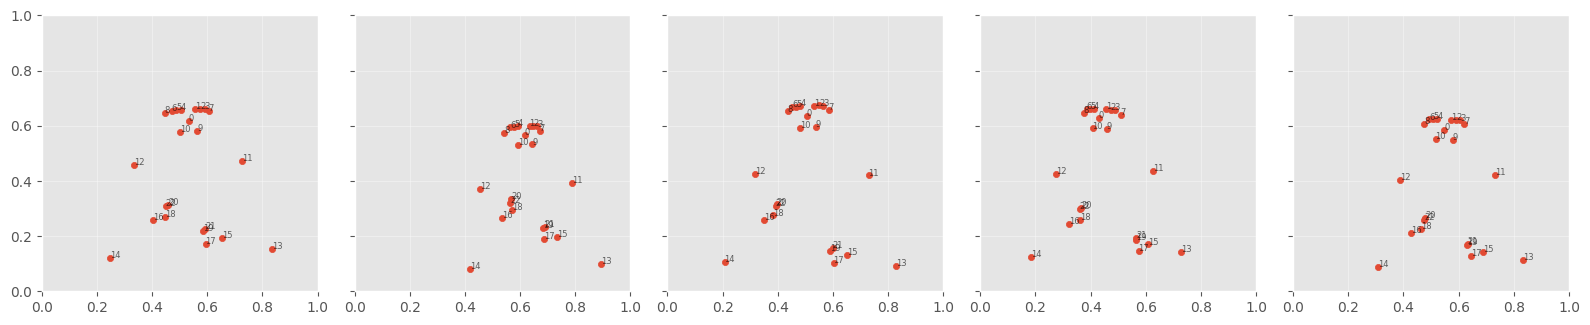

--- Wrist-position heatmap per signer (both wrists) ---


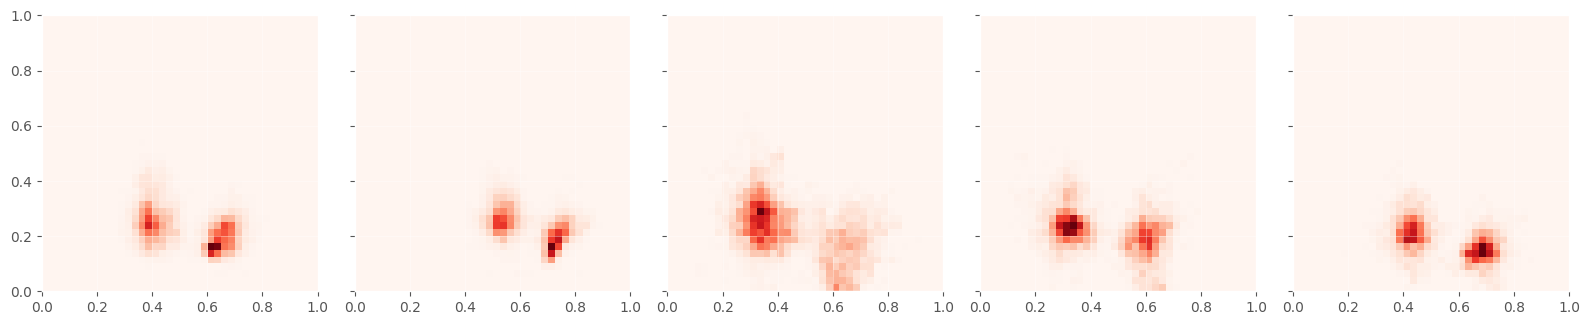

In [21]:
# MediaPipe Holistic body landmark indices
BODY_N = 33
LEFT_WRIST_IDX = 15
RIGHT_WRIST_IDX = 16

# Holistic poses are flattened (T, 75*3) = body(33) + left_hand(21) + right_hand(21).
# Each joint is (x, y, visibility). x,y are normalized to [0, 1] (frame coordinates).
def load_pose(path):
    arr = np.load(path)  # (T, 225)
    return arr.reshape(arr.shape[0], 75, 3)


def aggregate_signer(signer_id, max_clips=80):
    """Sample up to max_clips per signer to keep memory bounded."""
    paths = [POSES_DIR / r["video_id"] / f"{r['clip_id']}.npy"
             for _, r in df[df["signer_id"] == signer_id].iterrows()]
    paths = [p for p in paths if p.exists()][:max_clips]
    if not paths:
        return None
    chunks = [load_pose(p) for p in paths]
    return np.concatenate(chunks, axis=0)  # (sumT, 75, 3)


signers = sorted(df["signer_id"].dropna().unique())
signers = [s for s in signers if s != ""]

print("--- Mean body pose per signer (33 MediaPipe keypoints) ---")
# --- Figure 1: mean pose per signer ---
fig, axes = plt.subplots(1, len(signers), figsize=(3.2 * len(signers), 4), sharey=True)
if len(signers) == 1:
    axes = [axes]

for ax, sid in zip(axes, signers):
    poses = aggregate_signer(sid)
    if poses is None:
        continue
    body = poses[:, :BODY_N, :]  # (T, 33, 3)
    visible = body[..., 2] > 0.3
    mean_xy = np.where(visible[..., None], body[..., :2], np.nan)
    mean_xy = np.nanmean(mean_xy, axis=0)  # (33, 2)
    ax.scatter(mean_xy[:, 0], 1 - mean_xy[:, 1], s=20)  # invert y for display
    for i in range(BODY_N):
        ax.annotate(str(i), (mean_xy[i, 0], 1 - mean_xy[i, 1]), fontsize=6, alpha=0.6)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
plt.tight_layout()
savefig("mean_pose_per_signer")
plt.show()


print("--- Wrist-position heatmap per signer (both wrists) ---")
# --- Figure 2: wrist-position heatmap per signer (both wrists overlaid) ---
fig, axes = plt.subplots(1, len(signers), figsize=(3.2 * len(signers), 4), sharex=True, sharey=True)
if len(signers) == 1:
    axes = [axes]

for ax, sid in zip(axes, signers):
    poses = aggregate_signer(sid)
    if poses is None:
        continue
    pts = []
    for idx in (LEFT_WRIST_IDX, RIGHT_WRIST_IDX):
        wxy = poses[:, idx, :2]
        vis = poses[:, idx, 2] > 0.3
        pts.append(wxy[vis])
    pts = np.concatenate(pts, axis=0)
    if len(pts) == 0:
        continue
    h, xe, ye = np.histogram2d(pts[:, 0], 1 - pts[:, 1], bins=40,
                               range=[[0, 1], [0, 1]])
    ax.imshow(h.T, origin="lower", extent=[0, 1, 0, 1],
              aspect="equal", cmap="Reds")
plt.tight_layout()
savefig("wrist_heatmap_per_signer")
plt.show()


## 8. Frame Budget

Total frame count and per-split breakdown — useful for justifying training-time and model-size decisions.

In [22]:
budget = pd.DataFrame({
    "split": SPLITS,
    "clips": [len(df[df["split"] == s]) for s in SPLITS],
    "frames": [int(df[df["split"] == s]["n_frames"].sum()) for s in SPLITS],
    "hours": [df[df["split"] == s]["duration_s"].sum() / 3600 for s in SPLITS],
})
budget["mean_frames_per_clip"] = (budget["frames"] / budget["clips"].replace(0, np.nan)).round(1)
budget["median_frames_per_clip"] = [
    int(df[df["split"] == s]["n_frames"].median()) if len(df[df["split"] == s]) else 0
    for s in SPLITS
]

# Append a TOTAL row
total = pd.DataFrame([{
    "split": "TOTAL",
    "clips": int(budget["clips"].sum()),
    "frames": int(budget["frames"].sum()),
    "hours": float(budget["hours"].sum()),
    "mean_frames_per_clip": round(budget["frames"].sum() / max(budget["clips"].sum(), 1), 1),
    "median_frames_per_clip": int(df["n_frames"].median()),
}])
budget = pd.concat([budget, total], ignore_index=True)

print(budget.round(2).to_string(index=False))
budget.to_csv(TABLES_DIR / "frame_budget.csv", index=False)
with open(TABLES_DIR / "frame_budget.tex", "w") as f:
    f.write(budget.round(2).to_latex(index=False))


split  clips  frames  hours  mean_frames_per_clip  median_frames_per_clip
train   1691  294652   2.73                 174.2                     144
  dev    211   35032   0.32                 166.0                     131
 test    212   36582   0.34                 172.6                     122
TOTAL   2114  366266   3.39                 173.3                     141


## 9. Summary

In [23]:
import json as _json

print("=" * 60)
print("  SUMMARY")
print("=" * 60)
print(f"\nDataset: {len(df)} clips, {df['duration_s'].sum()/3600:.2f} hours")
print(f"Videos: {df['video_id'].nunique()}")
print(f"Signers: {df['signer_id'].nunique()}")
print(f"Total frames: {int(df['n_frames'].sum()):,}")
print()

per_split = {}
for split in SPLITS:
    s = df[df["split"] == split]
    per_split[split] = {
        "clips": int(len(s)),
        "hours": float(s["duration_s"].sum() / 3600),
        "frames": int(s["n_frames"].sum()),
        "videos": int(s["video_id"].nunique()),
        "avg_clip_s": float(s["duration_s"].mean()) if len(s) else None,
    }
    avg = f"{s['duration_s'].mean():.1f}" if len(s) else "—"
    print(f"{split:>12}: {len(s):>5} clips, {s['duration_s'].sum()/3600:.2f}h, "
          f"{s['video_id'].nunique()} videos, avg {avg}s/clip")

print(f"\n--- Potential issues ---")
print(f"Clips < {MIN_DURATION_S}s: {len(df[df['duration_s'] < MIN_DURATION_S])}")
print(f"Clips > {MAX_DURATION_S}s: {len(df[df['duration_s'] > MAX_DURATION_S])}")
print(f"Missing poses: {len(df[df['n_frames'] == 0])}")
print(f"Single-token clips: {len(df[df['n_tokens'] < MIN_TOKENS])}")

# Save machine-readable stats for cross-reference into the thesis text
stats = {
    "totals": {
        "clips": int(len(df)),
        "hours": float(df["duration_s"].sum() / 3600),
        "frames": int(df["n_frames"].sum()),
        "videos": int(df["video_id"].nunique()),
        "signers": int(df["signer_id"].nunique()),
    },
    "per_split": per_split,
    "qc_thresholds": {
        "min_duration_s": MIN_DURATION_S,
        "max_duration_s": MAX_DURATION_S,
        "min_tokens": MIN_TOKENS,
        "token_rate_outlier_q": TOKEN_RATE_OUTLIER_Q,
    },
    "flagged_counts": {
        "short": int(df["flag_short"].sum()),
        "long": int(df["flag_long"].sum()),
        "no_pose": int(df["flag_no_pose"].sum()),
        "single_token": int(df["flag_single_tok"].sum()),
        "high_rate": int(df["flag_high_rate"].sum()),
        "low_rate": int(df["flag_low_rate"].sum()),
        "any": int(df["flag_any"].sum()),
    },
}
out_path = TABLES_DIR / "dataset_stats.json"
out_path.write_text(_json.dumps(stats, indent=2, ensure_ascii=False))
print(f"\nStats written to {out_path}")


  SUMMARY

Dataset: 2114 clips, 3.39 hours
Videos: 11
Signers: 5
Total frames: 366,266

       train:  1691 clips, 2.73h, 11 videos, avg 5.8s/clip
         dev:   211 clips, 0.32h, 11 videos, avg 5.5s/clip
        test:   212 clips, 0.34h, 11 videos, avg 5.8s/clip

--- Potential issues ---
Clips < 1.0s: 47
Clips > 30.0s: 9
Missing poses: 0
Single-token clips: 22

Stats written to /Users/xandro/code/diploma/ucu-text-to-sign/reports/tables/dataset/dataset_stats.json
